In [40]:
import pyodbc


conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=DESKTOP-TNKBTJD\SQLEXPRESS;'  
    'DATABASE=Egypt_Energy_Data;'  
    'Trusted_Connection=yes;'  
)

cursor = conn.cursor()
cursor.execute("SELECT @@VERSION") 
for row in cursor:
    print(row)

conn.close()


('Microsoft SQL Server 2022 (RTM) - 16.0.1000.6 (X64) \n\tOct  8 2022 05:58:25 \n\tCopyright (C) 2022 Microsoft Corporation\n\tExpress Edition (64-bit) on Windows 10 Pro 10.0 <X64> (Build 22631: )\n',)


<>:6: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:6: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\hp\AppData\Local\Temp\ipykernel_8936\2958465468.py:6: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  'SERVER=DESKTOP-TNKBTJD\SQLEXPRESS;'


In [41]:
import pyodbc
import pandas as pd

def connect_to_sql_server():
    try:
       
        conn = pyodbc.connect(
            'DRIVER={ODBC Driver 17 for SQL Server};'
            'SERVER=DESKTOP-TNKBTJD\SQLEXPRESS;'  
            'DATABASE=Egypt_Energy_Data;'  
            'Trusted_Connection=yes;'  
        )
        return conn
    except pyodbc.Error as e:
        print(f"خطأ في الاتصال: {e}")
        return None

def read_data_from_sql(conn, query):
    if conn:
        try:
            df = pd.read_sql(query, conn)
            return df
        except Exception as e:
            print(f"خطأ أثناء قراءة البيانات: {e}")
            return None
    return None

def close_connection(conn):
    if conn:
        conn.close()
        print("تم إغلاق الاتصال بنجاح.")

if __name__ == "__main__":
    conn = connect_to_sql_server()
    query = """
        select year , Gas_Production
from Egypt_Energy_Project
where country = 'Egypt'
order by year;
        """  
    df = read_data_from_sql(conn, query)
    
    if df is not None:
       
        
       print(df.head())  
    else:
        print("لم يتم العثور على بيانات.")
    
   
    close_connection(conn)


   year  Gas_Production
0  2000      202.125000
1  2001      242.550003
2  2002      262.763000
3  2003      289.713013
4  2004      317.625000
تم إغلاق الاتصال بنجاح.


<>:9: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:9: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\hp\AppData\Local\Temp\ipykernel_8936\2216478499.py:9: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  'SERVER=DESKTOP-TNKBTJD\SQLEXPRESS;'
C:\Users\hp\AppData\Local\Temp\ipykernel_8936\2216478499.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


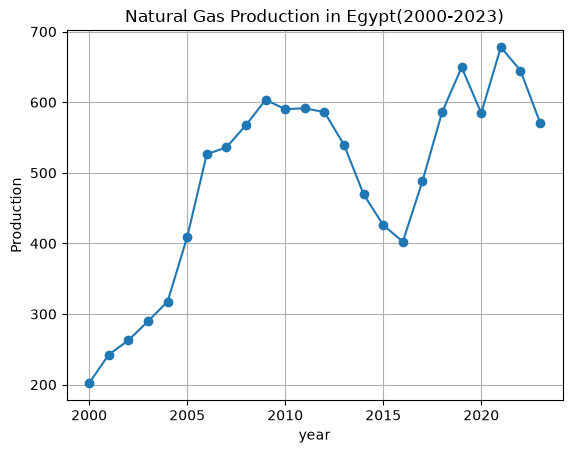

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.Figure(figsize=(10,5))
plt.plot(df['year'], df['Gas_Production'],marker='o')
plt.title('Natural Gas Production in Egypt(2000-2023)')
plt.xlabel('year')
plt.ylabel('Production')
plt.grid(True)
plt.show()

In [43]:
conn = connect_to_sql_server()
query = """
   select year,electricity_generation
from Egypt_Energy_Project
where country = 'Egypt'
order by year;
    """  
df = read_data_from_sql(conn, query)

if df is not None:
    
    print(df.head(55))   
else:
    print("لم يتم العثور على بيانات.")


close_connection(conn)

    year  electricity_generation
0   2000               73.320000
1   2001               80.709999
2   2002               86.230003
3   2003               92.190002
4   2004               98.250000
5   2005              104.940002
6   2006              111.660004
7   2007              119.860001
8   2008              128.800003
9   2009              134.270004
10  2010              144.429993
11  2011              149.559998
12  2012              162.839996
13  2013              165.080002
14  2014              171.240005
15  2015              181.830002
16  2016              188.190002
17  2017              193.210007
18  2018              199.389999
19  2019              200.570007
20  2020              198.600006
21  2021              209.660004
22  2022              216.720001
23  2023              221.919998
تم إغلاق الاتصال بنجاح.


C:\Users\hp\AppData\Local\Temp\ipykernel_8936\2216478499.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


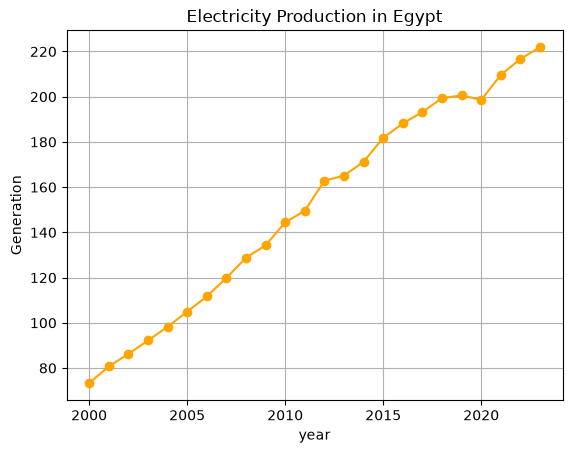

In [44]:
plt.Figure(figsize=(10,5))
plt.plot(df['year'],df['electricity_generation'],marker='o',color='orange')
plt.title('Electricity Production in Egypt')
plt.xlabel('year')
plt.ylabel('Generation')
plt.grid(True)
plt.show()

In [45]:
conn = connect_to_sql_server()
query = """
   select year,electricity_demand
from Egypt_Energy_Project
where country = 'Egypt'
order by year;
    """  
df = read_data_from_sql(conn, query)

if df is not None:
    
    print(df.head(55))   
else:
    print("لم يتم العثور على بيانات.")


close_connection(conn)

    year  electricity_demand
0   2000           73.169998
1   2001           80.500000
2   2002           85.449997
3   2003           91.269997
4   2004           97.550003
5   2005          104.160004
6   2006          111.309998
7   2007          119.300003
8   2008          127.900002
9   2009          133.330002
10  2010          142.990005
11  2011          147.979996
12  2012          162.440002
13  2013          164.679993
14  2014          170.559998
15  2015          181.139999
16  2016          187.919998
17  2017          192.869995
18  2018          198.820007
19  2019          199.779999
20  2020          197.179993
21  2021          208.190002
22  2022          215.149994
23  2023          220.529999
تم إغلاق الاتصال بنجاح.


C:\Users\hp\AppData\Local\Temp\ipykernel_8936\2216478499.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


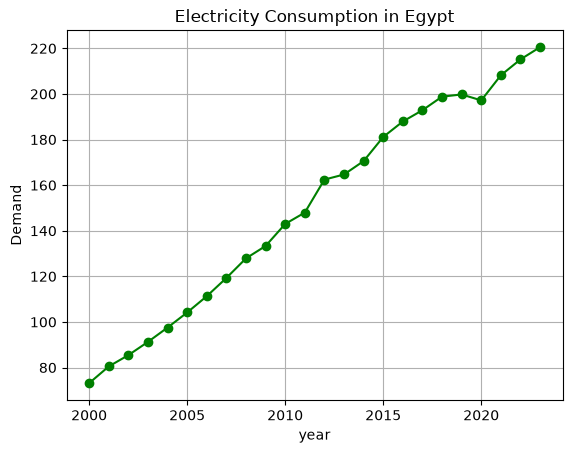

In [46]:
plt.Figure(figsize=(8,4))
plt.plot(df['year'],df['electricity_demand'],marker='o',color='green')
plt.title('Electricity Consumption in Egypt')
plt.xlabel('year')
plt.ylabel('Demand')
plt.grid(True)
plt.show()

In [47]:
conn = connect_to_sql_server()
query = """
  select gas_production,electricity_generation
from Egypt_Energy_Project
where country = 'Egypt'
    """  
df = read_data_from_sql(conn, query)

if df is not None:
    
    print(df.head(55))   
else:
    print("لم يتم العثور على بيانات.")


close_connection(conn)

    gas_production  electricity_generation
0       202.125000               73.320000
1       242.550003               80.709999
2       262.763000               86.230003
3       289.713013               92.190002
4       317.625000               98.250000
5       409.062012              104.940002
6       526.487000              111.660004
7       536.015991              119.860001
8       567.585999              128.800003
9       603.390991              134.270004
10      590.205017              144.429993
11      591.432983              149.559998
12      585.981995              162.839996
13      539.648010              165.080002
14      469.610992              171.240005
15      425.906006              181.830002
16      402.516998              188.190002
17      488.113007              193.210007
18      585.590027              199.389999
19      649.388000              200.570007
20      584.651978              198.600006
21      677.994019              209.660004
22      644

C:\Users\hp\AppData\Local\Temp\ipykernel_8936\2216478499.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


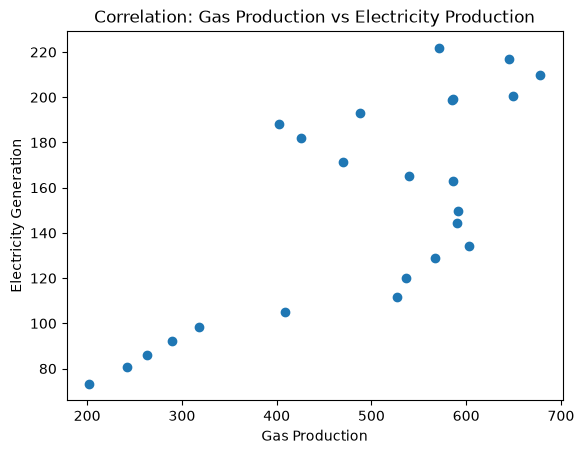

In [48]:
plt.Figure(figsize=(8,4))
plt.scatter(df['gas_production'],df['electricity_generation'])
plt.title('Correlation: Gas Production vs Electricity Production')
plt.xlabel('Gas Production')
plt.ylabel('Electricity Generation')
plt.show()

In [49]:
conn = connect_to_sql_server()
query = """
 select year,(electricity_generation - electricity_demand) as balance
from Egypt_Energy_Project
where country = 'Egypt';
    """  
df = read_data_from_sql(conn, query)

if df is not None:
    
    print(df.head(55))   
else:
    print("لم يتم العثور على بيانات.")


close_connection(conn)

    year   balance
0   2000  0.150002
1   2001  0.209999
2   2002  0.780006
3   2003  0.920006
4   2004  0.699997
5   2005  0.779999
6   2006  0.350006
7   2007  0.559998
8   2008  0.900002
9   2009  0.940002
10  2010  1.439987
11  2011  1.580002
12  2012  0.399994
13  2013  0.400009
14  2014  0.680008
15  2015  0.690002
16  2016  0.270004
17  2017  0.340012
18  2018  0.569992
19  2019  0.790009
20  2020  1.420013
21  2021  1.470001
22  2022  1.570007
23  2023  1.389999
تم إغلاق الاتصال بنجاح.


C:\Users\hp\AppData\Local\Temp\ipykernel_8936\2216478499.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


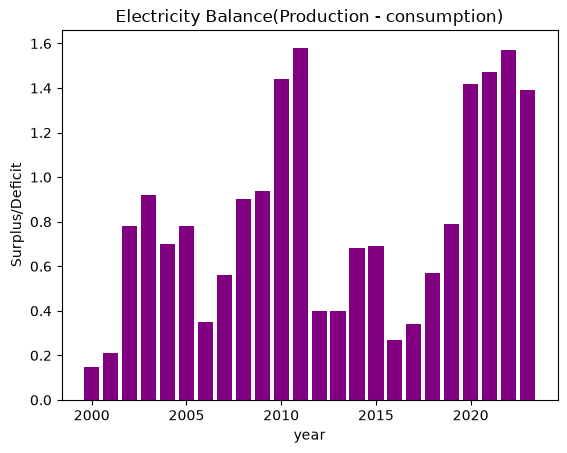

In [51]:
plt.Figure(figsize=(10,5))
plt.bar(df['year'],df['balance'],color='purple')
plt.title('Electricity Balance(Production - consumption)')
plt.xlabel('year')
plt.ylabel('Surplus/Deficit')
plt.show()

In [52]:
conn = connect_to_sql_server()
query = """
 select year, net_elec_imports
from Egypt_Energy_Project
where country = 'Egypt'
and year >= 2018;
    """  
df = read_data_from_sql(conn, query)

if df is not None:
    
    print(df.head(55))   
else:
    print("لم يتم العثور على بيانات.")


close_connection(conn)

   year  net_elec_imports
0  2018             -0.57
1  2019             -0.79
2  2020             -1.42
3  2021             -1.47
4  2022             -1.57
5  2023             -1.39
تم إغلاق الاتصال بنجاح.


C:\Users\hp\AppData\Local\Temp\ipykernel_8936\2216478499.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


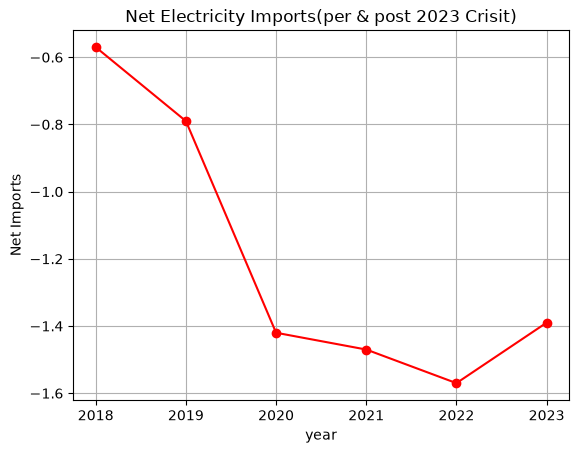

In [53]:
plt.Figure(figsize=(10,5))
plt.plot(df['year'],df['net_elec_imports'],marker='o',color='red')
plt.title('Net Electricity Imports(per & post 2023 Crisit)')
plt.xlabel('year')
plt.ylabel('Net Imports')
plt.grid(True)
plt.show()

In [54]:
conn = connect_to_sql_server()
query = """
 select country,AVG(electricity_generation) as avg_production
from Egypt_Energy_Project
group by country 
order by avg_production desc;
    """  
df = read_data_from_sql(conn, query)

if df is not None:
    
    print(df.head(55))   
else:
    print("لم يتم العثور على بيانات.")


close_connection(conn)

                 country  avg_production
0           Saudi Arabia      278.125000
1           South Africa      246.108750
2                   Iran      246.061666
3                 Turkey      227.630416
4                  Egypt      151.394585
5   United Arab Emirates      100.042916
6                   Iraq       65.992084
7                 Israel       59.825834
8                Algeria       55.445416
9                  Libya       28.888750
10               Nigeria       28.382500
11               Morocco       26.611667
12               Tunisia       16.744167
13                Jordan       15.516667
14                 Sudan        9.617917
15              Ethiopia        8.184167
تم إغلاق الاتصال بنجاح.


C:\Users\hp\AppData\Local\Temp\ipykernel_8936\2216478499.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


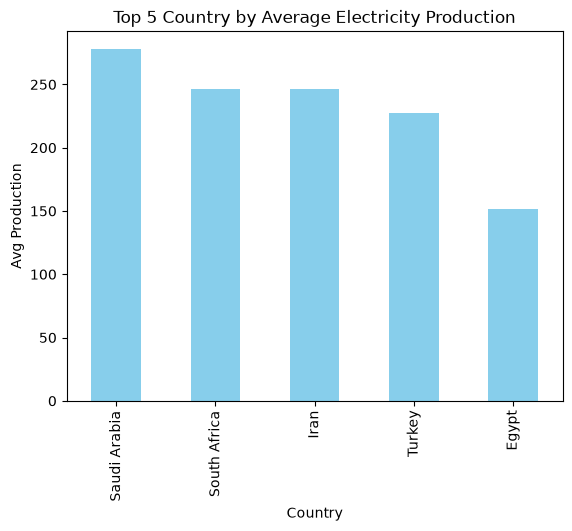

In [61]:
avg_prod = df.groupby('country')['avg_production'].mean().sort_values(ascending=False).head(5)
plt.Figure(figsize=(10,5))
avg_prod.plot(kind='bar',color='skyblue')
plt.title('Top 5 Country by Average Electricity Production')
plt.xlabel('Country')
plt.ylabel('Avg Production')
plt.show()

In [62]:
conn = connect_to_sql_server()
query = """
 select year , ABS(electricity_generation - LAG(electricity_generation) over (order by year))
AS annual_volatility
from Egypt_Energy_Project
where country = 'Egypt';
    """  
df = read_data_from_sql(conn, query)

if df is not None:
    
    print(df.head(55))   
else:
    print("لم يتم العثور على بيانات.")


close_connection(conn)

    year  annual_volatility
0   2000                NaN
1   2001           7.389999
2   2002           5.520004
3   2003           5.959999
4   2004           6.059998
5   2005           6.690002
6   2006           6.720001
7   2007           8.199997
8   2008           8.940002
9   2009           5.470001
10  2010          10.159988
11  2011           5.130005
12  2012          13.279999
13  2013           2.240005
14  2014           6.160004
15  2015          10.589996
16  2016           6.360001
17  2017           5.020004
18  2018           6.179993
19  2019           1.180008
20  2020           1.970001
21  2021          11.059998
22  2022           7.059998
23  2023           5.199997
تم إغلاق الاتصال بنجاح.


C:\Users\hp\AppData\Local\Temp\ipykernel_8936\2216478499.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


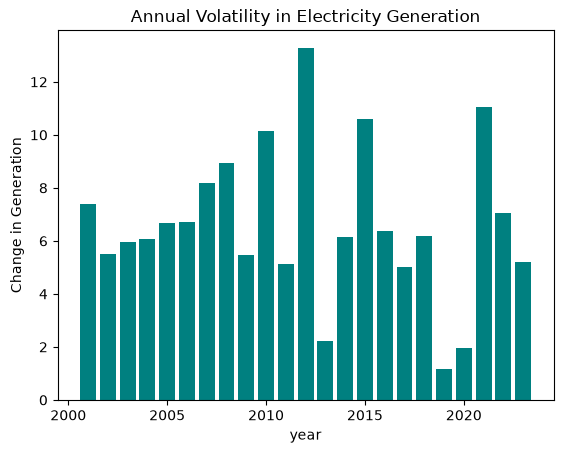

In [65]:
plt.Figure(figsize=(10,5))
plt.bar(df['year'],df['annual_volatility'],color='teal')
plt.title('Annual Volatility in Electricity Generation')
plt.xlabel('year')
plt.ylabel('Change in Generation')
plt.show()

In [66]:
conn = connect_to_sql_server()
query = """
 select year, gas_production, electricity_generation
from Egypt_Energy_Project
where country = 'Egypt' AND year
between 2015 AND 2020;
    """  
df = read_data_from_sql(conn, query)

if df is not None:
    
    print(df.head(55))   
else:
    print("لم يتم العثور على بيانات.")


close_connection(conn)

   year  gas_production  electricity_generation
0  2015      425.906006              181.830002
1  2016      402.516998              188.190002
2  2017      488.113007              193.210007
3  2018      585.590027              199.389999
4  2019      649.388000              200.570007
5  2020      584.651978              198.600006
تم إغلاق الاتصال بنجاح.


C:\Users\hp\AppData\Local\Temp\ipykernel_8936\2216478499.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


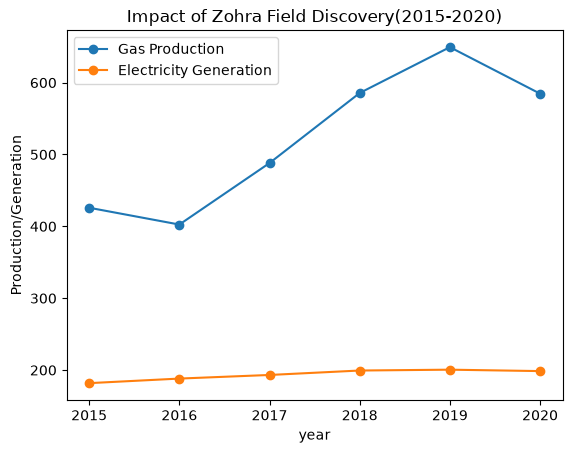

In [67]:
zohr_period = df[(df['year'] >= 2015)&(df['year'] <= 2020)]
plt.Figure(figsize=(10,5))
plt.plot(zohr_period['year'],zohr_period['gas_production'],label='Gas Production',marker='o')
plt.plot(zohr_period['year'],zohr_period['electricity_generation'],label='Electricity Generation',marker='o')
plt.title('Impact of Zohra Field Discovery(2015-2020)')
plt.xlabel('year')
plt.ylabel('Production/Generation')
plt.legend()
plt.show()

In [68]:
conn = connect_to_sql_server()
query = """
 SELECT year, electricity_generation, electricity_demand
FROM Egypt_Energy_Project
WHERE country = 'Egypt' AND year >= 2020;
    """  
df = read_data_from_sql(conn, query)

if df is not None:
    
    print(df.head(55))   
else:
    print("لم يتم العثور على بيانات.")


close_connection(conn)

   year  electricity_generation  electricity_demand
0  2020              198.600006          197.179993
1  2021              209.660004          208.190002
2  2022              216.720001          215.149994
3  2023              221.919998          220.529999
تم إغلاق الاتصال بنجاح.


C:\Users\hp\AppData\Local\Temp\ipykernel_8936\2216478499.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


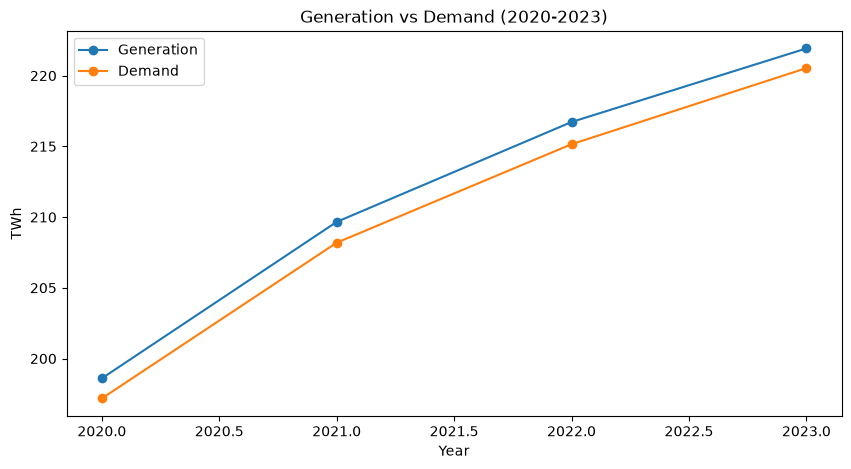

In [69]:
crisis_period = df[df['year'] >= 2020]
plt.figure(figsize=(10, 5))
plt.plot(crisis_period['year'], crisis_period['electricity_generation'], label='Generation', marker='o')
plt.plot(crisis_period['year'], crisis_period['electricity_demand'], label='Demand', marker='o')
plt.title('Generation vs Demand (2020-2023)')
plt.xlabel('Year')
plt.ylabel('TWh')
plt.legend()
plt.show()

In [70]:
conn = connect_to_sql_server()
query = """
 SELECT year, fossil_share_elec, renewables_share_elec
FROM Egypt_Energy_Project
WHERE country = 'Egypt' AND year >= 2015;
    """  
df = read_data_from_sql(conn, query)

if df is not None:
    
    print(df.head(55))   
else:
    print("لم يتم العثور على بيانات.")


close_connection(conn)

   year  fossil_share_elec  renewables_share_elec
0  2015          91.415001                  8.585
1  2016          91.587997                  8.412
2  2017          91.977997                  8.022
3  2018          91.745003                  8.255
4  2019          90.233002                  9.767
5  2020          88.036003                 11.964
6  2021          87.903999                 12.096
7  2022          88.182999                 11.817
8  2023          88.297997                 11.702
تم إغلاق الاتصال بنجاح.


C:\Users\hp\AppData\Local\Temp\ipykernel_8936\2216478499.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


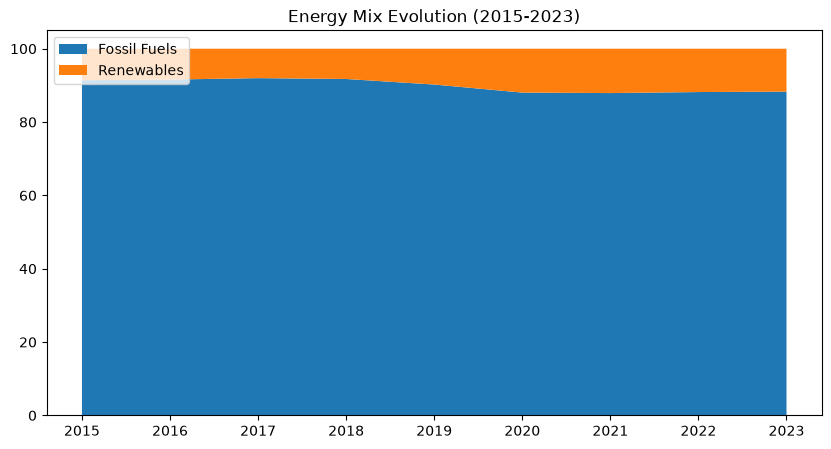

In [71]:
plt.figure(figsize=(10, 5))
plt.stackplot(df['year'][df['year']>=2015], 
              df['fossil_share_elec'][df['year']>=2015], 
              df['renewables_share_elec'][df['year']>=2015], 
              labels=['Fossil Fuels', 'Renewables'])
plt.title('Energy Mix Evolution (2015-2023)')
plt.legend(loc='upper left')
plt.show()

In [72]:
conn = connect_to_sql_server()
query = """
SELECT year, gdp_worldbank_usd, electricity_demand
FROM Egypt_Energy_Project
WHERE country = 'Egypt';
    """  
df = read_data_from_sql(conn, query)

if df is not None:
    
    print(df.head(55))   
else:
    print("لم يتم العثور على بيانات.")


close_connection(conn)

    year  gdp_worldbank_usd  electricity_demand
0   2000       9.983854e+10           73.169998
1   2001       9.668464e+10           80.500000
2   2002       8.514607e+10           85.449997
3   2003       8.028846e+10           91.269997
4   2004       7.878246e+10           97.550003
5   2005       8.966034e+10          104.160004
6   2006       1.074260e+11          111.309998
7   2007       1.304380e+11          119.300003
8   2008       1.628180e+11          127.900002
9   2009       1.891470e+11          133.330002
10  2010       2.189840e+11          142.990005
11  2011       2.359900e+11          147.979996
12  2012       2.791170e+11          162.440002
13  2013       2.884340e+11          164.679993
14  2014       3.055950e+11          170.559998
15  2015       3.293670e+11          181.139999
16  2016       3.324420e+11          187.919998
17  2017       2.483630e+11          192.869995
18  2018       2.625890e+11          198.820007
19  2019       3.186790e+11          199

C:\Users\hp\AppData\Local\Temp\ipykernel_8936\2216478499.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


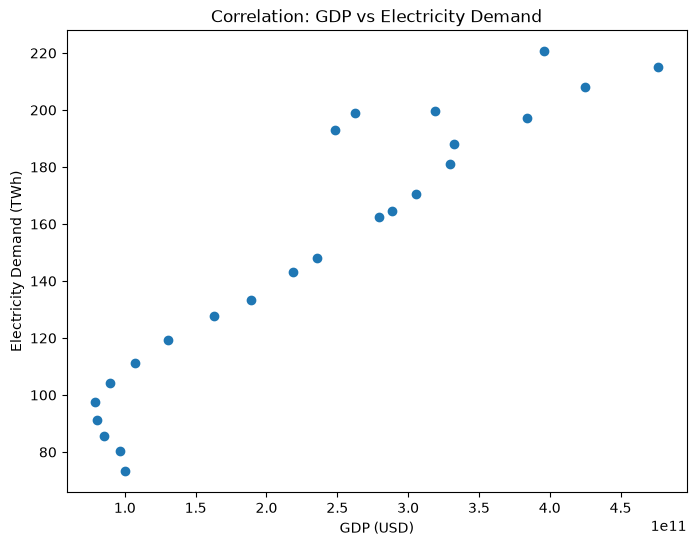

In [73]:
plt.figure(figsize=(8, 6))
plt.scatter(df['gdp_worldbank_usd'],df['electricity_demand'])
plt.title('Correlation: GDP vs Electricity Demand')
plt.xlabel('GDP (USD)')
plt.ylabel('Electricity Demand (TWh)')
plt.show()